In [19]:
import numpy as np
np_df = np.load('5_10_gene_high_var_sergio.npy')
np_df

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(300, 2500))

In [20]:
import anndata as ad
import scanpy as sc
import pandas as pd

gene_names = [f"Gene_{i+1}" for i in range(300)]
cell_names = [f"Cell_{i+1}" for i in range(2500)]
cell_types = [f"Type{(i // 500) + 1}" for i in range(2500)]

adata = ad.AnnData(
    X=np_df.T,
    obs=pd.DataFrame(
        {
            "cell_type": cell_types
        },
        index=cell_names
    ),
    var=pd.DataFrame(index=gene_names)
)
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
adata.obs["tf_mean"] = np.asarray(
    adata[:, :30].X.mean(axis=1)
).ravel()
adata.obs["gene_mean"] = np.asarray(
    adata[:, 30:].X.mean(axis=1)
).ravel()
adata

AnnData object with n_obs × n_vars = 2500 × 300
    obs: 'cell_type', 'tf_mean', 'gene_mean'
    uns: 'log1p'

In [3]:
adata.obs

,cell_type,tf_mean,gene_mean
Cell_1,Type1,0.043551,0.120526
Cell_2,Type1,0.076383,0.122509
Cell_3,Type1,0.039039,0.107434
Cell_4,Type1,0.021430,0.105034
Cell_5,Type1,0.018274,0.113624
...,...,...,...
Cell_2496,Type5,0.077736,0.111198
Cell_2497,Type5,0.033952,0.086541
Cell_2498,Type5,0.094596,0.110573
Cell_2499,Type5,0.100943,0.086426


In [3]:
sc.tl.pca(adata, svd_solver='arpack')
# Step 3: Compute neighbors
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/data1/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-29 15:58:55.745471: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 15:58:55.792531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 15:58:56.848639: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see

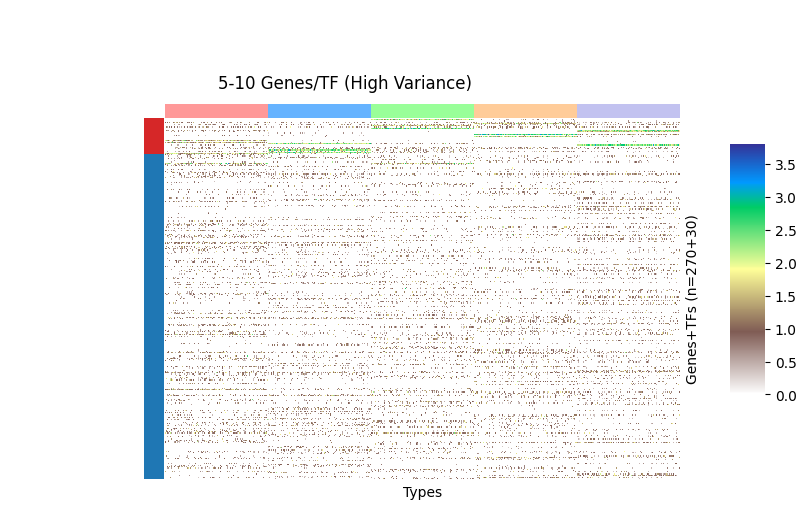

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Prepare the color logic for Y (Rows)
# First 30 are 'TF', the rest are 'Gene'
num_rows = adata.X.T.shape[0]
row_tags = ['TF'] * 30 + ['Gene'] * (num_rows - 30)
row_colors_map = {'TF': 'tab:red', 'Gene': 'tab:blue'}
row_colors = pd.Series(row_tags).map(row_colors_map)

# 2. Prepare the color logic for X (Columns)
# Divide into 5 equal parts with 4 distinct colors (repeating or unique)
num_cols = adata.X.T.shape[1]
col_divisions = np.linspace(0, num_cols, 6).astype(int)
col_colors_list = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0'] # 5 colors for 5 parts
col_tags = []
for i in range(5):
    size = col_divisions[i+1] - col_divisions[i]
    col_tags.extend([col_colors_list[i]] * size)
col_colors = pd.Series(col_tags)

# 3. Create the Plot using Clustermap
# We disable clustering (row_cluster=False, col_cluster=False) to keep it as a standard heatmap
g = sns.clustermap(
    adata.X.T,
    cmap="terrain_r",
    row_cluster=False, 
    col_cluster=False,
    row_colors=row_colors.values,
    col_colors=col_colors.values,
    xticklabels=False,
    yticklabels=False,
    figsize=(7, 5),
    # This moves the legend to the right side of the heatmap
    cbar_pos=(1.05, 0.2, 0.05, 0.5)
)
# g.cbar_ax.set_visible(False)
# 4. Add custom legends for the color bars
# from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor='tab:red', label='TFs (n=30)'),
#     Patch(facecolor='tab:blue', label='Genes (n=270)')
# ]
# plt.legend(handles=legend_elements, bbox_to_anchor=(2, 1), loc='upper left')
# plt.tight_layout()
ax = g.ax_heatmap
ax.set_xlabel("Types")
ax.set_ylabel("Genes+TFs (n=270+30)")
g.fig.suptitle("5-10 Genes/TF (High Variance)", y=0.84)
g.savefig('heatmap_5_10_gene_high_var_sergio.png', dpi=600, bbox_inches='tight')
plt.show()

In [5]:
cov_cells = np.cov(adata.X)
cov_cells

array([[ 0.11809047,  0.05035406,  0.04084977, ..., -0.00277423,
         0.00332682, -0.00086114],
       [ 0.05035406,  0.12765228,  0.05569619, ...,  0.00542762,
         0.00140297,  0.00448056],
       [ 0.04084977,  0.05569619,  0.09252927, ...,  0.00401978,
         0.00030475,  0.00077987],
       ...,
       [-0.00277423,  0.00542762,  0.00401978, ...,  0.12774573,
         0.05354524,  0.04290816],
       [ 0.00332682,  0.00140297,  0.00030475, ...,  0.05354524,
         0.11049871,  0.0527771 ],
       [-0.00086114,  0.00448056,  0.00077987, ...,  0.04290816,
         0.0527771 ,  0.12149038]], shape=(2500, 2500))

In [6]:
cov_genes = np.cov(adata.X.T)
cov_genes

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  5.68386589e-01, -2.10933896e-03, ...,
        -9.46033556e-03, -1.75668926e-02,  8.23166768e-02],
       [ 0.00000000e+00, -2.10933896e-03,  7.57125392e-03, ...,
        -6.53626867e-04,  4.07733838e-03, -2.31992652e-04],
       ...,
       [ 0.00000000e+00, -9.46033556e-03, -6.53626867e-04, ...,
         6.07492046e-02, -4.31849089e-03, -1.16642765e-03],
       [ 0.00000000e+00, -1.75668926e-02,  4.07733838e-03, ...,
        -4.31849089e-03,  1.70430194e-01, -1.05089632e-03],
       [ 0.00000000e+00,  8.23166768e-02, -2.31992652e-04, ...,
        -1.16642765e-03, -1.05089632e-03,  5.56027017e-02]],
      shape=(300, 300))

In [22]:
corr_genes = np.corrcoef(adata.X, rowvar=False)
corr_genes

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,  1.        , -0.03215441, ..., -0.05091132,
        -0.05644166,  0.46303943],
       [        nan, -0.03215441,  1.        , ..., -0.03047724,
         0.1135062 , -0.01130687],
       ...,
       [        nan, -0.05091132, -0.03047724, ...,  1.        ,
        -0.04244128, -0.02006964],
       [        nan, -0.05644166,  0.1135062 , ..., -0.04244128,
         1.        , -0.0107954 ],
       [        nan,  0.46303943, -0.01130687, ..., -0.02006964,
        -0.0107954 ,  1.        ]], shape=(300, 300))

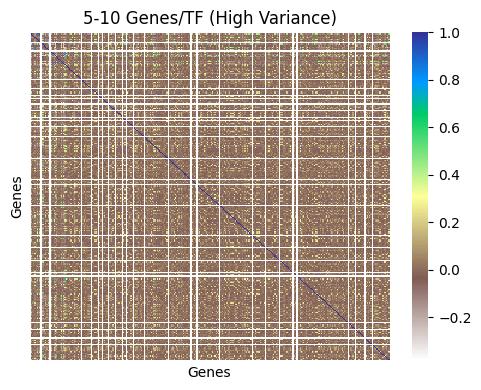

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

ax = sns.heatmap(corr_genes, cmap='terrain_r')

# Axis labeling
ax.set_xlabel("Genes")
ax.set_ylabel("Genes")
ax.set_xticks([])
ax.set_yticks([])
# Title
ax.set_title("5-10 Genes/TF (High Variance)")

plt.tight_layout()
plt.savefig('5_10_gene_high_var_sergio_gene_Correlation_Heatmap.png', dpi=1200, bbox_inches='tight')
plt.show()

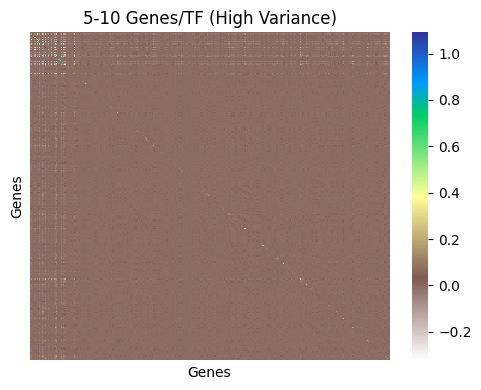

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

ax = sns.heatmap(cov_genes, cmap='terrain_r')

# Axis labeling
ax.set_xlabel("Genes")
ax.set_ylabel("Genes")
ax.set_xticks([])
ax.set_yticks([])
# Title
ax.set_title("5-10 Genes/TF (High Variance)")

plt.tight_layout()
plt.savefig('5_10_gene_high_var_sergio_gene_Covariance_Heatmap.png', dpi=1200, bbox_inches='tight')
plt.show()

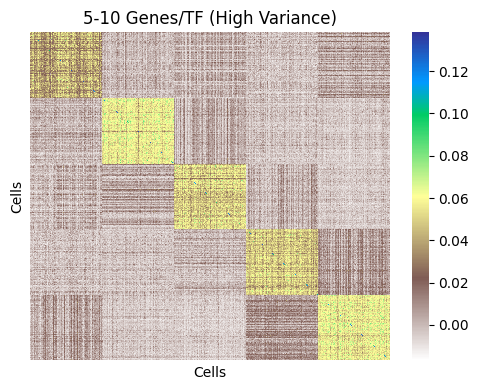

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

ax = sns.heatmap(cov_cells, cmap='terrain_r')

# Axis labeling
ax.set_xlabel("Cells")
ax.set_ylabel("Cells")
ax.set_xticks([])
ax.set_yticks([])
# Title
ax.set_title("5-10 Genes/TF (High Variance)")

plt.tight_layout()
plt.savefig('5_10_gene_high_var_sergio_cell_Covariance_Heatmap.png', dpi=1200, bbox_inches='tight')
plt.show()

In [10]:
import csv
import numpy as np

csv_file = "50_60_target.csv"

edges = []

sources = set()   # column 0
targets = set()   # column 2+

# Parse CSV
with open(csv_file, newline="") as f:
    reader = csv.reader(f)
    for row in reader:
        if len(row) < 2:
            continue

        src = row[0].strip()

        try:
            k = int(float(row[1]))
        except ValueError:
            continue

        tgts = [t.strip() for t in row[2:2 + k]]

        sources.add(src)
        for t in tgts:
            targets.add(t)
            edges.append((t, src))  # (row, column)

# Index mappings
sources = sorted(sources)
targets = sorted(targets)

src_to_idx = {s: i for i, s in enumerate(sources)}
tgt_to_idx = {t: i for i, t in enumerate(targets)}

# Rectangular adjacency matrix
adj = np.zeros((len(targets), len(sources)), dtype=int)

# Fill matrix
for t, s in edges:
    adj[tgt_to_idx[t], src_to_idx[s]] = 1

print("Adjacency matrix:\n", adj.shape)

Adjacency matrix:
 (30, 270)


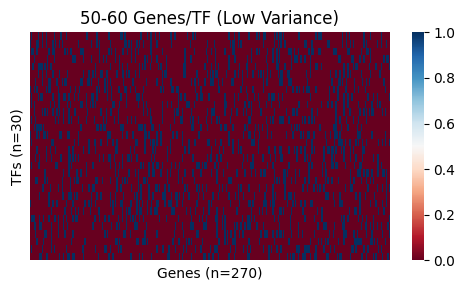

In [11]:
plt.figure(figsize=(5, 3))
sns.heatmap(adj, cmap='RdBu')
plt.xticks([])
plt.yticks([])
plt.xlabel("Genes (n=270)")
plt.ylabel("TFs (n=30)")
plt.title("50-60 Genes/TF (Low Variance)")
plt.tight_layout()
plt.savefig('network_heatmap_50_60_gene_low_var_sergio.png', dpi=600, bbox_inches='tight')
plt.show()

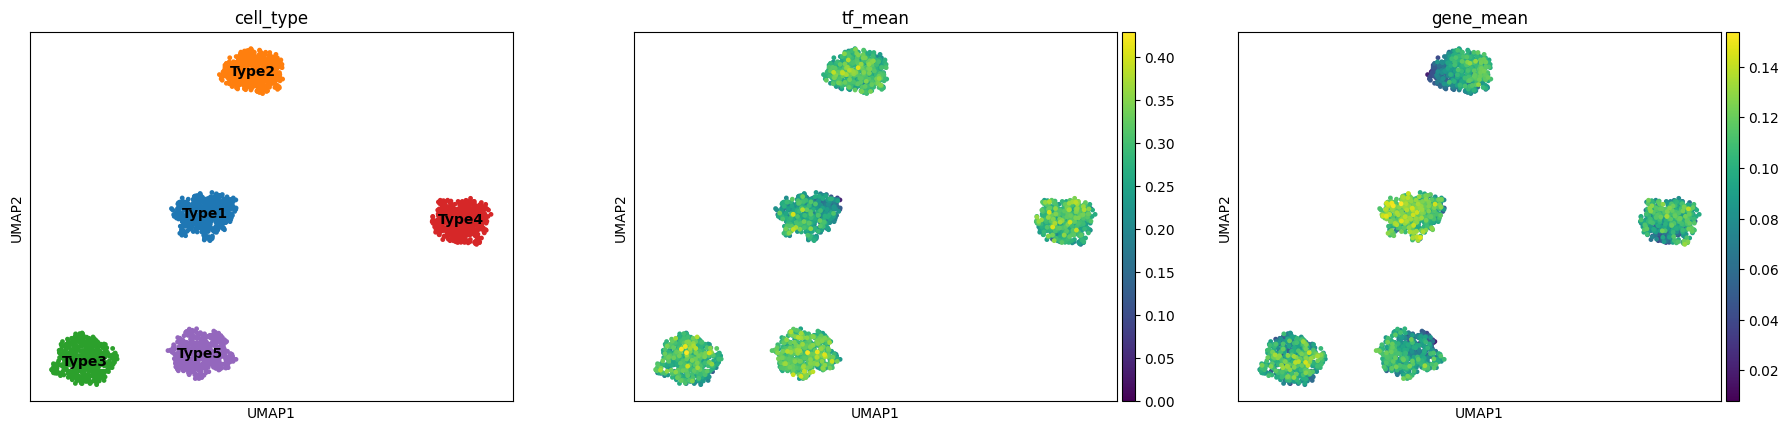

In [9]:
sc.pl.umap(
        adata,
        color=['cell_type', 'tf_mean', 'gene_mean'],
        legend_loc="on data",
        show=True,
        save=f"_5_10_gene_high_var_sergio.png"
    )

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path

# ===== USER SETTINGS =====
NPY_FOLDER = "./"   # <- CHANGE THIS
BLOCK_SIZE = 500   # cells per label type
# =========================


for npy_path in sorted(Path(NPY_FOLDER).glob("*.npy")):

    print("Processing:", npy_path.name)

    # Load matrix (genes x cells)
    data = np.load(npy_path)
    n_genes, n_cells = data.shape

    # Transpose -> cells x genes
    data = data.T

    # Build names
    gene_names = [f"Gene_{i+1}" for i in range(n_genes)]
    cell_names = [f"Cell_{i+1}" for i in range(n_cells)]

    # Build expression DataFrame
    expr_df = pd.DataFrame(data, index=cell_names, columns=gene_names)

    # Output filenames
    expr_out = npy_path.with_suffix(".csv")
    label_out = npy_path.with_name(f"meta_{npy_path.stem}.csv")

    # Save expression
    expr_df.to_csv(expr_out)

    # Generate labels
    labels = [f"Type{(i // BLOCK_SIZE) + 1}" for i in range(n_cells)]
    meta_df = pd.DataFrame({"": cell_names, "Label": labels})

    # Save labels
    meta_df.to_csv(label_out, index=False)

    print("Saved:", expr_out.name, "and", label_out.name)

print("All files processed.")

Processing: 30tf_18_20_gene_sergio.npy
Saved: 30tf_18_20_gene_sergio.csv and meta_30tf_18_20_gene_sergio.csv
Processing: 30tf_1_2_gene_sergio.npy
Saved: 30tf_1_2_gene_sergio.csv and meta_30tf_1_2_gene_sergio.csv
Processing: 30tf_4_5_gene_sergio.npy
Saved: 30tf_4_5_gene_sergio.csv and meta_30tf_4_5_gene_sergio.csv
Processing: 30tf_8_10_gene_sergio.npy
Saved: 30tf_8_10_gene_sergio.csv and meta_30tf_8_10_gene_sergio.csv
All files processed.
